# Simulating a blue-detuned MOT for RaFOH

In [1]:
B = 1.0 * 1e-4 # 10 Gauss
DETUNNING = 1.

6.0

In [2]:
using Pkg
Pkg.activate("/Users/jose/Documents/Works/MIT/RaX/Simu/Molecule-Sims/")
using
    Revise,
    QuantumStates,            # for calculating molecular structure
    OpticalBlochEquations,    # for solving optical Bloch equations
    UnitsToValue,              # for numerical values
    DifferentialEquations, # for differential equations (with
    Plots,                    # for plotting
    PlotlyJS,              # for interactive plots
    Statistics,              # for statistics
    LinearAlgebra,       # for linear algebra
    StaticArrays,        # for static arrays
    DataFrames           # for data frames
;

  Activating project at `~/Documents/Works/MIT/RaX/Simu/Molecule-Sims`


In [3]:
# Get the basis element with the maximum coefficient from the state
function get_max_coeff_basis_element(state)
    coeffs = abs.(state.coeffs) .^ 2
    max_idx = argmax(coeffs)
    return state.basis[max_idx]
end

# Extract quantum numbers from the basis element with the maximum coefficient
function extract_quantum_numbers_from_state(state)
    basis_elem = get_max_coeff_basis_element(state)
    quantum_numbers = Dict(:N => basis_elem.N, :J => basis_elem.J, :F => basis_elem.F, :M => basis_elem.M)
    return quantum_numbers
end

# Get the J quantum number from the basis element with the maximum coefficient
function get_J_quantum_number(state)
    basis_elem = get_max_coeff_basis_element(state)
    return basis_elem.J
end

# Search for a state in a list of states by specific quantum numbers
function find_state_by_quantum_numbers(states, N, J, F, M)
    for state in states
        qn = extract_quantum_numbers_from_state(state)
        if qn[:N] == N && qn[:J] == J && qn[:F] == F && qn[:M] == M
            return state
        end
    end
    error("State with quantum numbers N=$N, J=$J, F=$F, M=$M not found.")
end
function all_state_info(state)
    basis_elem = get_max_coeff_basis_element(state)
    return basis_elem
end

_μB = (μB / h) * 1e-4;

In [4]:
QN_bounds = (
    S = 1/2,
    I = 1/2,
    Λ = 0,
    N = 0:3
)
X_state_basis = enumerate_states(HundsCaseB_LinearMolecule, QN_bounds)

X_state_operator = :(
    BX * Rotation +                     #
    DX * RotationDistortion +
    γX * SpinRotation +                 # Spin-rotation interaction
    bFX * Hyperfine_IS +
    cX * (Hyperfine_Dipolar/3)
)

# Now we have to plug in the constants for RaF:
# Taken from: https://www.nature.com/articles/s41567-023-02296-w
# If the results are being taken in

X_state_parameters = QuantumStates.@params begin
    # BX = 0.191985* c * 1e2
    BX = 5755.56e6
    # DX = 1.405 * (1e-7) * c * 1e2
    DX = 0.00420e6
    γX = 0.00585* c * 1e2
    # γX = 175.38e6
    bFX = 96.3e6
    cX = 19e6
end

X_state_ham = Hamiltonian(basis=X_state_basis, operator=X_state_operator, parameters=X_state_parameters)


Zeeman_x(state, state′) = (Zeeman(state, state′,-1) - Zeeman(state, state′,1))/sqrt(2)
Zeeman_y(state, state′) = im*(Zeeman(state, state′,-1) + Zeeman(state, state′,1))/sqrt(2)
Zeeman_z(state, state′) = Zeeman(state, state′, 0)

X_state_ham = add_to_H(X_state_ham, :B_x, (gS * _μB * 1e-6) * Zeeman_x)
X_state_ham = add_to_H(X_state_ham, :B_y, (gS * _μB * 1e-6) * Zeeman_y)
X_state_ham = add_to_H(X_state_ham, :B_z, (gS * _μB * 1e-6) * Zeeman_z)
X_state_ham.parameters.B_x = 0.
X_state_ham.parameters.B_y = B * 1/sqrt(2)
X_state_ham.parameters.B_z = B * 1/sqrt(2)

evaluate!(X_state_ham)
QuantumStates.solve!(X_state_ham)
all_grounds = X_state_ham.states[5:16]
ground_states = [state for state in all_grounds if extract_quantum_numbers_from_state(state)[:N]== 1]


12-element Vector{State{HundsCaseB_LinearMolecule}}:
 State{HundsCaseB_LinearMolecule}(1.1320615764007502e10, HundsCaseB_LinearMolecule[HundsCaseB_LinearMolecule(0.0, "", 0, 0, 0, 1/2, 1/2, 0, 0, 0, 0, 1/2, 0, 0, (K = 0, N = 0:∞, J = 0.5:1.0:0.5, F = 0.0:1.0:1.0, M = 0.0:1.0:0.0)), HundsCaseB_LinearMolecule(0.0, "", 0, 0, 0, 1/2, 1/2, 0, 0, 0, 0, 1/2, 1, -1, (K = 0, N = 0:∞, J = 0.5:1.0:0.5, F = 0.0:1.0:1.0, M = -1.0:1.0:1.0)), HundsCaseB_LinearMolecule(0.0, "", 0, 0, 0, 1/2, 1/2, 0, 0, 0, 0, 1/2, 1, 0, (K = 0, N = 0:∞, J = 0.5:1.0:0.5, F = 0.0:1.0:1.0, M = -1.0:1.0:1.0)), HundsCaseB_LinearMolecule(0.0, "", 0, 0, 0, 1/2, 1/2, 0, 0, 0, 0, 1/2, 1, 1, (K = 0, N = 0:∞, J = 0.5:1.0:0.5, F = 0.0:1.0:1.0, M = -1.0:1.0:1.0)), HundsCaseB_LinearMolecule(0.0, "", 0, 0, 0, 1/2, 1/2, 0, 0, 0, 1, 1/2, 0, 0, (K = 0, N = 0:∞, J = 0.5:1.0:1.5, F = 0.0:1.0:1.0, M = 0.0:1.0:0.0)), HundsCaseB_LinearMolecule(0.0, "", 0, 0, 0, 1/2, 1/2, 0, 0, 0, 1, 1/2, 1, -1, (K = 0, N = 0:∞, J = 0.5:1.0:1.5, F = 0.0:1.0:1

In [5]:
QN_bounds = (
    S = 1/2,
    I = 1/2,
    Λ = (-1,1),
    J = 1/2:3/2 # ?
)
A_state_basis = enumerate_states(HundsCaseA_LinearMolecule, QN_bounds)

A_state_operator = :(
    T_A * DiagonalOperator +
    Be_A * Rotation +
    Aso_A * SpinOrbit +
    q_A * ΛDoubling_q +
    p_A * ΛDoubling_p2q + q_A * (2ΛDoubling_p2q) +
    a * Hyperfine_IL +
    d * Hyperfine_Dipolar_d
)

# Spectroscopic constants for CaOH, A state
A_state_parameters = QuantumStates.@params begin
    T_A = (2067.6/2+13284.427) * c * 1e2 # Diagonal constant (electrion zero point energy)
    Be_A = 0.191 * c * 1e2# Rotational constant
    Aso_A = 2067.6 * c * 1e2# 1.405 * (1e-7) # A spin-orbit constant
    # Lambda doubling
    p_A = −0.41071 * c * 1e2
    q_A = 0
    a = 19/2 * 1e6
    d = -9e6
end

A_state_ham = Hamiltonian(basis=A_state_basis, operator=A_state_operator, parameters=A_state_parameters)
evaluate!(A_state_ham)
QuantumStates.solve!(A_state_ham)
A_J12 = [state for state in A_state_ham.states if get_J_quantum_number(state) == 1/2]
A_state_J12_pos_parity_states = A_J12[5:8]

QN_bounds = (
    S = 1/2,
    I = 1/2,
    Λ = (-1,1),
    N = 0:3 # ?
)
A_state_caseB_basis = enumerate_states(HundsCaseB_LinearMolecule, QN_bounds)

excited_states = convert_basis(A_state_J12_pos_parity_states, A_state_caseB_basis)
states = [ground_states; excited_states]
;

In [6]:
d = zeros(ComplexF64, 16, 16, 3)
d_ge = zeros(ComplexF64, 12, 4, 3)

basis_tdms = get_tdms_two_bases(X_state_ham.basis, A_state_caseB_basis, TDM)
tdms_between_states!(d_ge, basis_tdms, ground_states, excited_states)
d[1:12, 13:16, :] .= d_ge
;

### Zeeman plot for the $X^2\Sigma^+(N=1)$ state in RaF

In [7]:
# A few constants used for the simulation
λ = 1e-2/13324 # Wavelength of light in meters
Γ = 2π/(34e-9) # 34 ns
m = @with_unit 245 "u" # Mass of the molecule in atomic mass units
k = 2π / λ
;

In [8]:
Aenergies = [energy(st) for st in excited_states]
Xenergies = [energy(st) for st in ground_states]

ground_quantum_numbers = [extract_quantum_numbers_from_state(st) for st in ground_states]
excited_quantum_numbers = [extract_quantum_numbers_from_state(st) for st in excited_states]

X_Js = [qn[:J] for qn in ground_quantum_numbers]
X_Ms = [qn[:M] for qn in ground_quantum_numbers]
X_Fs = [qn[:F] for qn in ground_quantum_numbers]
X_Ns = [qn[:N] for qn in ground_quantum_numbers]
A_Js = [qn[:J] for qn in excited_quantum_numbers]
A_Ms = [qn[:M] for qn in excited_quantum_numbers]
A_Fs = [qn[:F] for qn in excited_quantum_numbers]
A_Ns = [qn[:N] for qn in excited_quantum_numbers]

df = DataFrame(
    J = [A_Js; X_Js],
    M = [A_Ms; X_Ms],
    F = [A_Fs; X_Fs],
    N = [A_Ns; X_Ns],
    energy = [Aenergies; Xenergies],
    state = [["A" for _ in Aenergies]; ["X" for _ in Xenergies]]
)

# Sort the DataFrame by energy and then M
sort!(df, [:energy, :M, :F, :J, :N]);
# PlotlyJS.plot(
#     PlotlyJS.scatter(
#         x = df.N[df.state .== "X"],
#         y = df.energy[df.state .== "X"],
#         mode = "markers",
#         marker = attr(
#             size = 10,
#             color = df.M,
#             colorscale = "Viridis",
#             colorbar = attr(title = "M"),
#             showscale = true
#         ),
#         text = ["J: $(df.J[i]), M: $(df.M[i]), F: $(df.F[i]), N: $(df.N[i])" for i in 1:length(df.energy)],
#         hoverinfo = "text",
#         name = "A and X states",
#         type = "scatter"
#     ),
# )

Row,J,M,F,N,energy,state
,Half…,Half…,Half…,Half…,Float64,String
1,1/2,-1,1,1,1.13206e10,X
2,1/2,1,1,1,1.13206e10,X
3,1/2,0,1,1,1.13206e10,X
4,1/2,0,0,1,1.13535e10,X
5,3/2,-1,1,1,1.15689e10,X
6,3/2,0,1,1,1.15689e10,X
7,3/2,1,1,1,1.15689e10,X
8,3/2,-2,2,1,1.16222e10,X
9,3/2,-2,2,1,1.16222e10,X


# Setup the laser scheme

source states:

 - All N=1 states of the $X^2\Sigma^+(000)$ state

Target states:

 - State $J=1/2+$ states of the $A^2\Pi_{1/2}(000)$ with $N=1$

In [9]:
n_excited = length(excited_states)
# source states
g_interest_states = [state for state in all_grounds]
input_energies = [energy(st) for st in g_interest_states]
# Target states
a_qns =[extract_quantum_numbers_from_state(st) for st in excited_states][1]
energies = [energy(st) for st in excited_states]
# sorted
target_states = sort(excited_states, by = energy)
target_energy = [energy(st) for st in excited_states][1];
delta_state_energies = target_energy .- input_energies
# J12_energies = [energy(s) for s in input_states][1]
δJ12 = DETUNNING*Γ # Detuning for J=1/2 state

A_energy = target_energy
ω_J12s = [2π * (A_energy - inp_e) + δJ12 for inp_e in input_energies]
ω_J12 = ω_J12s[1]
s_func(s) = (r,t) -> s
I_sat =  π*h*c*Γ/(3λ^3) / 10
s_J12 = s_func(10.0)
# Sidebands
ratios = [1, 1/2, 1/2, 0]
s_J12_sidebands = [s_func(ratio * 10.0) for ratio in ratios]
pol_J12 = σ⁺ # Polarization for J=1/2
polarizations = [pol_J12 for _ in 1:length(pol_J12)]
ϵ(ϵ_val) = t -> ϵ_val;

In [ ]:
use_single_state = true
if use_single_state

    # Define the wave vectors and polarizations for the lasers in the XY‖ configuration
    k̂ = +x̂; ϵ1 = ϵ(rotate_pol(pol_J12, ẑ)); laser1 = Field(k̂, ϵ1, ω_J12, s_J12)
    k̂ = -x̂; ϵ2 = ϵ(rotate_pol(pol_J12, -ẑ)); laser2 = Field(k̂, ϵ2, ω_J12, s_J12)
    k̂ = +ŷ; ϵ3 = ϵ(rotate_pol(pol_J12, ẑ)); laser3 = Field(k̂, ϵ3, ω_J12, s_J12)
    k̂ = -ŷ; ϵ4 = ϵ(rotate_pol(pol_J12, -ẑ)); laser4 = Field(k̂, ϵ4, ω_J12, s_J12)

    lasers_XY_parallel = [laser1, laser2, laser3, laser4]
    # Define the wave vectors and polarizations for the lasers in the XY⊥ configuration
    k̂ = +x̂; ϵ1 = ϵ(rotate_pol(pol_J12, ŷ)); laser1 = Field(k̂, ϵ1, ω_J12, s_J12)
    k̂ = -x̂; ϵ2 = ϵ(rotate_pol(pol_J12, -ŷ)); laser2 = Field(k̂, ϵ2, ω_J12, s_J12)
    k̂ = +ŷ; ϵ3 = ϵ(rotate_pol(pol_J12, ẑ)); laser3 = Field(k̂, ϵ3, ω_J12, s_J12)
    k̂ = -ŷ; ϵ4 = ϵ(rotate_pol(pol_J12, -ẑ)); laser4 = Field(k̂, ϵ4, ω_J12, s_J12)

    lasers_XY_perpendicular = [laser1, laser2, laser3, laser4];
else

    lasers_plus_x = [Field(+x̂, ϵ, ω, s) for (ϵ, j, ω, s) in zip([ϵ(rotate_pol(pol_J12, ẑ)) for j in 1:length(ω_J12s)], polarizations, ω_J12s, s_J12_sidebands)]
    lasers_minus_x = [Field(-x̂, ϵ, ω, s) for (ϵ, j, ω, s) in zip([ϵ(rotate_pol(pol_J12, -ẑ)) for j in 1:length(ω_J12s)], polarizations, ω_J12s, s_J12_sidebands)]
    lasers_plus_y = [Field(+ŷ, ϵ, ω, s) for (ϵ, j, ω, s) in zip([ϵ(rotate_pol(pol_J12, ẑ)) for j in 1:length(ω_J12s)], polarizations, ω_J12s, s_J12_sidebands)]
    lasers_minus_y = [Field(-ŷ, ϵ, ω, s) for (ϵ, j, ω, s) in zip([ϵ(rotate_pol(pol_J12, -ẑ)) for j in 1:length(ω_J12s)], polarizations, ω_J12s, s_J12_sidebands)]
    lasers_XY_parallel = [lasers_plus_x; lasers_minus_x; lasers_plus_y; lasers_minus_y]

    laser_plus_x = [Field(+x̂, ϵ, ω, s) for (ϵ, j, ω, s) in zip([ϵ(rotate_pol(pol_J12, ŷ)) for j in 1:length(ω_J12s)], polarizations, ω_J12s, s_J12_sidebands)]
    laser_minus_x = [Field(-x̂, ϵ, ω, s) for (ϵ, j, ω, s) in zip([ϵ(rotate_pol(pol_J12, -ŷ)) for j in 1:length(ω_J12s)], polarizations, ω_J12s, s_J12_sidebands)]
    laser_plus_y = [Field(+ŷ, ϵ, ω, s) for (ϵ, j, ω, s) in zip([ϵ(rotate_pol(pol_J12, ẑ)) for j in 1:length(ω_J12s)], polarizations, ω_J12s, s_J12_sidebands)]
    laser_minus_y = [Field(-ŷ, ϵ, ω, s) for (ϵ, j, ω, s) in zip([ϵ(rotate_pol(pol_J12, -ẑ)) for j in 1:length(ω_J12s)], polarizations, ω_J12s, s_J12_sidebands)]
    lasers_XY_perpendicular = [laser_plus_x; laser_minus_x; laser_plus_y; laser_minus_y];
end

In [11]:
lasers = lasers_XY_parallel

12-element Vector{Field{Float64, var"#63#64"{SVector{3, ComplexF64}}, var"#57#58"{Float64}}}:
 Field{Float64, var"#63#64"{SVector{3, ComplexF64}}, var"#57#58"{Float64}}([1.0, 0.0, 0.0], var"#63#64"{SVector{3, ComplexF64}}(ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 1.0 + 0.0im]), ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im], 2.5023277828323405e15, var"#57#58"{Float64}(10.0), 0.0, 0.0, 0.0, 0.0, ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im])
 Field{Float64, var"#63#64"{SVector{3, ComplexF64}}, var"#57#58"{Float64}}([1.0, 0.0, 0.0], var"#63#64"{SVector{3, ComplexF64}}(ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 1.0 + 0.0im]), ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im], 2.5023277828323405e15, var"#57#58"{Float64}(5.0), 0.0, 0.0, 0.0, 0.0, ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 0.0 + 0.0im])
 Field{Float64, var"#63#64"{SVector{3, ComplexF64}}, var"#57#58"{Float64}}([1.0, 0.0, 0.0], var"#63#64"{SVector{3, ComplexF64}}(ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 1.0 + 0.0im]), ComplexF64[0.0 + 0.0i

In [12]:
# Set initial conditions
particle = OpticalBlochEquations.Particle()
ρ0 = zeros(ComplexF64, length(states), length(states))
# names = [
# "M = $(st.basis[i].M), J = $(st.basis[i].J), F = $(st.basis[i].F))" for (i, st) in enumerate(states)]
names = [extract_quantum_numbers_from_state(st) for st in states]
string_names = ["|$(qn[:J]),  $(qn[:F]), $(qn[:M])>" for qn in names]
ρ0[1,1] = 1.0

freq_res = 1e-2
p = obe(ρ0, particle, states, lasers, d, true, true; λ=λ, Γ=Γ, freq_res=freq_res)
;

After defining `p`, we're free to update any of its parameters before solving the OBEs. For example, we can update the initial position `r0` to $\mathbf{r}_0 = (0,0,0.5)~k^{-1}$ and the velocity `v` to $\mathbf{v} = (0,0,1)~\text{m/s}$ as shown below. Note that position and velocity need to have units of 1/k and Γ/k in the simulation, so since we defined the velocity in SI units it must be divided by Γ/k. We also need to round the velocity again (using `round_vel`) after updating it (this rounding is automatically performed inside `obe` when `p` is first defined but must be performed again if `v` is changed).

In [13]:
p.r0 = (0., 0., 0.)
p.v = (0., 0., 1.0) ./ (Γ / k)
p.v = round_vel(p.v, p.freq_res)
;

Finally, we define a time span for the solver (here in terms of the period defined by `freq_res`, which is given by `p.period`). The actual solving is performed using the `DifferentialEquations` package in Julia, so we load this here as well. This package requires a `prob` variable of type `ODEProblem`. The cell below shows the syntax for how this variable is created for the OBE solver.

After solving, we can plot the populations as a function of time, and the force averaged over one period can be found in `prob.p.force_last_period`. Note that the force output in the simulation has units ħkΓ.

 13.465379 seconds (12.86 M allocations: 828.543 MiB, 3.08% gc time, 64.17% compilation time)

Force (10³ m/s): [-1.4316400939292547e40, -1.4316400939292547e40, 0.0]

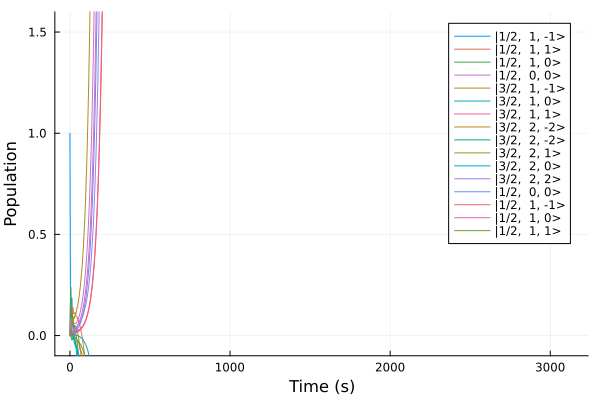

In [14]:
using DifferentialEquations
using Plots
t_end = 5p.period+1
tspan = (0., t_end)
prob = ODEProblem(ρ!, p.ρ0_vec, tspan, p)
times = range(0, t_end, 1000)

cb = PeriodicCallback(reset_force!, p.period)
@time sol = DifferentialEquations.solve(prob, DP5(), callback=cb, reltol=1e-3, saveat=times)

# Print the force
println()
print("Force (10³ m/s): ", prob.p.force_last_period * (1e-3 * ħ * k * Γ / m))

using Plots
plot_us = sol.u
plot_ts = sol.t

n_states = size(p.ρ_soa, 1)
Plots.plot(
    ylim=(-0.1, 1.6),
)

for i in 1:n_states
    state_idx = n_states*(i-1) + i # For the diagonal elements
    Plots.plot!(plot_ts, [real(u[state_idx]) for u in plot_us], label=string_names[i])
end


# # plot!()
# offset = 0
# vline!([sol.t[end] - prob.p.period - offset, sol.t[end] - offset], color="red", linestyle=:dash)
# Add the correct axis labels
Plots.plot!(
    xlabel="Time (s)",
    ylabel="Population"
)
# Add the legends to each plot


Creating a "force profile" (i.e., the force as a function of some variable) can be performed by combining the previous section with the function `force_scan_v3`. The function takes in a `prob` for the OBEs (which we already defined above) and a `scan_values_grid` (essentially a grid of all the values we wish to scan over). Note that `scan_values_grid` may be multidimensional, e.g., we may wish to scan over both position and velocity simultaneously. Indeed, a profile of force versus velocity typically involves averaging over a collection of different starting positions from $\mathbf{r} = (0,0,0)$ to $\mathbf{r} = (2\pi, 2\pi, 2\pi)$ (in units of 1/k), or $\mathbf{r} = (0,0,0)$ to $\mathbf{r} = (\lambda, \lambda, \lambda)$ (in SI units). This ensures that the force is averaged over all possible initial values of the combined laser field seen by the molecule.

Two additional arguments are also required for `force_scan_v3`:
* `prob_func!` _(prob, scan_params, i) -> prob_: Updates the initial `prob` for the `i`th value of the `scan_values_grid`.
* `output_func` _(p, sol) -> force_: Define the output of the solver after `prob` has been solved, typically the force.

In [15]:
using
    StaticArrays,
    RectiGrids,
    StatsBase

In [16]:
function prob_func!(prob, scan_values_grid, i)
    p = prob.p
    # Update velocity and position
    p.v .= (0,scan_values_grid[i].v,0)
    p.v .= round_vel(p.v, p.freq_res)
    p.r0 .= scan_values_grid[i].r
    return prob
end
function output_func(p, sol)
    f = p.force_last_period
    return (f[1], 0, 0)
end
;

In [17]:
freq_res = 1e-1
p = obe(ρ0, particle, states, lasers, d, true, true; λ=λ, Γ=Γ, freq_res=freq_res)

t_end = 10p.period+1; tspan = (0., t_end)
prob = ODEProblem(ρ!, p.ρ0_vec, tspan, p, reltol=1e-3, save_on=false)

di = 2
rs = vcat([(n1/(di+1), n2/(di+1), n3/(di+1)) .* 2π for n1 ∈ 0:di, n2 ∈ 0:di, n3 ∈ 0:di]...)
vs = 0:0.5:7.0

scan_values = (r = rs, v = vs)
scan_values_grid = RectiGrids.grid(scan_values)
;

In [18]:
@time forces, populations = force_scan_v2(prob, scan_values_grid, prob_func!, output_func);

Progress:  20%|████████▎                                |  ETA: 0:05:25

In [ ]:
averaged_forces = Float64[]
@time for (i,v) ∈ enumerate(vs)
    idxs = [j for (j,x) ∈ enumerate(scan_values_grid) if x.v == v]
    push!(averaged_forces, mean([f[1] for f in forces[idxs]]))
end

In [ ]:
Plots.plot(vs, (1e-3 * ħ * k * Γ / m) .* averaged_forces,
    xlabel="Velocity (m/s)",
    ylabel="a (10³ m/s²) - x direction",
    framestyle=:box,
    linewidth=2.5,
    legend=nothing
    )